# 🫀 Framingham Heart Study — Data Cleaning Notebook

> **Dataset:** Framingham Heart Study (Kaggle)  
> **Goal:** Clean raw data → prepare it for EDA and supervised learning (CHD risk prediction)  
> **Author:** *(your name)*  
> **Date:** *(date)*

---

## 📋 Table of Contents
1. [Import Libraries](#1-import-libraries)
2. [Load Raw Data](#2-load-raw-data)
3. [Initial Inspection](#3-initial-inspection)
4. [Rename Columns](#4-rename-columns)
5. [Decode Binary & Categorical Columns](#5-decode-binary--categorical-columns)
6. [Handle Missing Values](#6-handle-missing-values)
7. [Data Type Validation](#7-data-type-validation)
8. [Outlier Check](#8-outlier-check)
9. [Final Cleaned Dataset](#9-final-cleaned-dataset)
10. [Export](#10-export)

---

## 1. Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.2f}'.format)

# Plot style
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams.update({'figure.dpi': 120, 'axes.titlesize': 13})

print('✅ Libraries loaded successfully')

✅ Libraries loaded successfully


## 2. Load Raw Data

In [ ]:
# ── Load the raw CSV ─────────────────────────────────────────────────────────

RAW_PATH = '../Data/0_raw_data/framingham.csv'
CLEANED_PATH = '../Data/1_cleaned_data/framingham_cleaned.csv'

df_raw = pd.read_csv(RAW_PATH)

# Keep a pristine copy — never mutate the original
df = df_raw.copy()

print(f'Rows : {df.shape[0]:,}')
print(f'Cols : {df.shape[1]}')


Rows : 4,240
Cols : 16


,male,age,education,currentSmoker,cigsPerDay,BPMeds,prevalentStroke,prevalentHyp,diabetes,totChol,sysBP,diaBP,BMI,heartRate,glucose,TenYearCHD
0,1,39,4.00,0,0.00,0.00,0,0,0,195.00,106.00,70.00,26.97,80.00,77.00,0
1,0,46,2.00,0,0.00,0.00,0,0,0,250.00,121.00,81.00,28.73,95.00,76.00,0
2,1,48,1.00,1,20.00,0.00,0,0,0,245.00,127.50,80.00,25.34,75.00,70.00,0
3,0,61,3.00,1,30.00,0.00,0,1,0,225.00,150.00,95.00,28.58,65.00,103.00,1
4,0,46,3.00,1,23.00,0.00,0,0,0,285.00,130.00,84.00,23.10,85.00,85.00,0


In [ ]:
## 3. Initial Inspection

In [9]:
# ── Schema & dtypes ──────────────────────────────────────────────────────────
print('=== dtypes & null counts ===')
info = pd.DataFrame({
    'dtype'     : df.dtypes,
    'non_null'  : df.notnull().sum(),
    'null_count': df.isnull().sum(),
    'null_%'    : (df.isnull().sum() / len(df) * 100).round(2)
})
display(info)

=== dtypes & null counts ===


,dtype,non_null,null_count,null_%
male,int64,4240,0,0.00
age,int64,4240,0,0.00
education,float64,4135,105,2.48
currentSmoker,int64,4240,0,0.00
cigsPerDay,float64,4211,29,0.68
BPMeds,float64,4187,53,1.25
prevalentStroke,int64,4240,0,0.00
prevalentHyp,int64,4240,0,0.00
diabetes,int64,4240,0,0.00
totChol,float64,4190,50,1.18


In [10]:
# ── Descriptive statistics ───────────────────────────────────────────────────
df.describe(include='all').T

,count,mean,std,min,25%,50%,75%,max
male,4240.00,0.43,0.50,0.00,0.00,0.00,1.00,1.00
age,4240.00,49.58,8.57,32.00,42.00,49.00,56.00,70.00
education,4135.00,1.98,1.02,1.00,1.00,2.00,3.00,4.00
currentSmoker,4240.00,0.49,0.50,0.00,0.00,0.00,1.00,1.00
cigsPerDay,4211.00,9.01,11.92,0.00,0.00,0.00,20.00,70.00
BPMeds,4187.00,0.03,0.17,0.00,0.00,0.00,0.00,1.00
prevalentStroke,4240.00,0.01,0.08,0.00,0.00,0.00,0.00,1.00
prevalentHyp,4240.00,0.31,0.46,0.00,0.00,0.00,1.00,1.00
diabetes,4240.00,0.03,0.16,0.00,0.00,0.00,0.00,1.00
totChol,4190.00,236.70,44.59,107.00,206.00,234.00,263.00,696.00


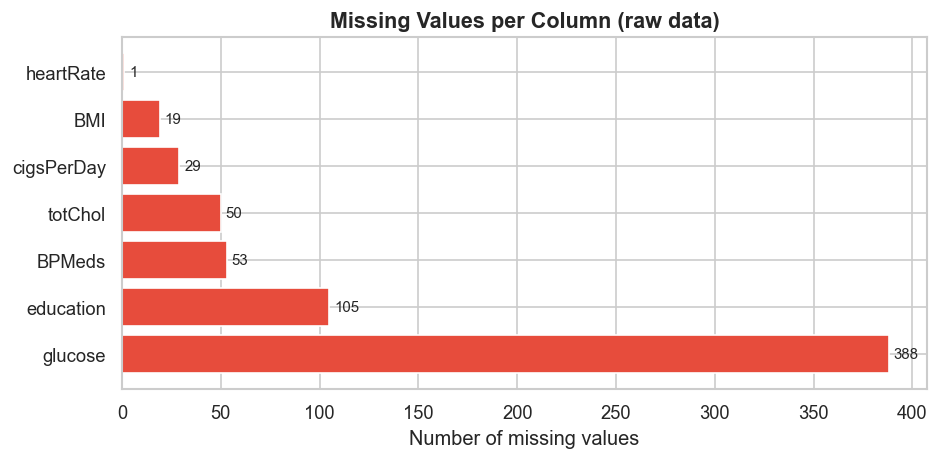


Total missing cells : 645
Total cells         : 67840
Missing %           : 0.95%


In [11]:
# ── Visualise missing values ─────────────────────────────────────────────────
null_counts = df.isnull().sum()
null_counts = null_counts[null_counts > 0].sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.barh(null_counts.index, null_counts.values, color='#E74C3C', edgecolor='white')
ax.bar_label(bars, padding=3, fontsize=9)
ax.set_title('Missing Values per Column (raw data)', fontweight='bold')
ax.set_xlabel('Number of missing values')
plt.tight_layout()
plt.show()

print(f'\nTotal missing cells : {df.isnull().sum().sum()}')
print(f'Total cells         : {df.size}')
print(f'Missing %           : {df.isnull().sum().sum() / df.size * 100:.2f}%')